# CSDA STAC search: multiple vendors' data at Sites

Summary:  
+ read in a sites geojson
+ compile a STAC search at site for a time period for vendor imagery
+ plot the footprints of the results
+ next step (todo) - how to access the image data for analysis?

| Author | Affiliation | Date |
| ---------------- | ---------------- | ---------------- |
| Paul Montesano, PhD | NASA Goddard Space Flight Center; ESSIC | July 2026 |

In [1]:
#pip install contextily
#pip install matplotlib_scalebar

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from urllib.parse import quote
import numpy as np

import sys

sys.path.append('/projects/code/csda_summaries/lib')
sys.path.append('/projects/code/geoscitools')
sys.path.append('/home/pmontesa/code/csda_summaries/lib')
sys.path.append('/home/pmontesa/code/geoscitools')

import csdalib
import staclib
import siteslib

from datetime import datetime
from multiprocessing import Pool, cpu_count
from functools import partial
from tqdm import tqdm
import importlib

/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3

## CSDA Evaluation Sites

Our database of `CSDA Evaluation Sites` is a critical & foundational set of information for CSDA SME work. Each site, uniquely identified with a `Site Name` and a specific geographic extent (AOI), provides some sort of radiometric or geometric reference for evaluation commercial imagery.

#### Read in our CSDA sites GeoJSON (AOIs) directly from GitHub

In [81]:
RAW_BASE = 'https://raw.githubusercontent.com/pahbs/csda_summaries/master'
sites_url = f'{RAW_BASE}/sites/eval_sites_aoi.geojson'
sites_gdf = gpd.read_file(sites_url)
print(f"{sites_gdf.shape[0]} CSDA site AOIs, which are extents of various sizes and shapes, ranging from tiny corner reflector locations, to boxes and circles, to larger custom polygons.")

611 CSDA site AOIs, which are extents of various sizes and shapes, ranging from tiny corner reflector locations, to boxes and circles, to larger custom polygons.


In [82]:
BUF_KM = 15

In [83]:
DO_SITE_SUBSET = True

In [84]:
if DO_SITE_SUBSET:
    #SITENAME = 'Bonanza_Creek'
    SITENAME = 'Boston'
    sites_gdf = sites_gdf[sites_gdf['Site Name'] == SITENAME]

#### Configure site AOIs for display in site maps down below

In [85]:
### Buffer MORE for sites for display
BUF_KM_ADD_FOR_DISPLAY = 25
BUF_KM_TOTAL_FOR_DISPLAY = BUF_KM_ADD_FOR_DISPLAY + BUF_KM

In [86]:
sites_gdf_buf = sites_gdf.to_crs(3857).buffer(BUF_KM_ADD_FOR_DISPLAY * 1000) # add arbitrary buffer to evaluation sites for map display
sites_gdf_buf_display = gpd.GeoDataFrame(sites_gdf.drop(columns=['geometry']), geometry=sites_gdf_buf, crs=sites_gdf_buf.crs).to_crs(4326)
sites_gdf_buf_display = sites_gdf_buf_display[~(sites_gdf_buf_display.geometry.is_empty | sites_gdf_buf_display.geometry.isna())]

# Table of CSDA STAC Collections

Here is what data we can find in the CSDA STAC

In [87]:
import requests
from IPython.display import Markdown, display

STAC_API_URL = 'https://csdap.earthdata.nasa.gov/stac'

# Get collections
response = requests.get(f'{STAC_API_URL}/collections')
data = response.json()

collections = data.get('collections', [])

# Build markdown
markdown_output = f"# CSDA STAC Collections\n\n"
markdown_output += f"**Total Collections:** {len(collections)}\n\n"
markdown_output += "| ID | Title | Description | Temporal Coverage |\n"
markdown_output += "|:---|:---|:---|:---|\n"

for collection in collections:
    col_id = collection.get('id', 'N/A')
    title = collection.get('title', 'N/A')
    description = collection.get('description', 'N/A')
    
    # Truncate and clean description
    if description and description != 'N/A':
        description = description.replace('\n', ' ').replace('\r', '')
        if len(description) > 100:
            description = description[:100] + '...'
        description = description.replace('|', '\\|')
    
    # Get temporal extent with safe None checks
    temporal_str = 'N/A'
    try:
        extent = collection.get('extent')
        if extent and isinstance(extent, dict):
            temporal = extent.get('temporal')
            if temporal and isinstance(temporal, dict):
                intervals = temporal.get('interval', [])
                if intervals and isinstance(intervals, list) and len(intervals) > 0:
                    if intervals[0] and isinstance(intervals[0], list) and len(intervals[0]) > 0:
                        start = intervals[0][0] if intervals[0][0] else 'Unknown'
                        end = intervals[0][1] if len(intervals[0]) > 1 and intervals[0][1] else 'Present'
                        
                        # Format dates nicely
                        if isinstance(start, str) and start not in ['Unknown', 'N/A']:
                            start = start.split('T')[0]
                        if isinstance(end, str) and end not in ['Present', 'N/A']:
                            end = end.split('T')[0]
                        
                        temporal_str = f"{start} to {end}"
    except Exception as e:
        # If anything goes wrong, just leave as N/A
        pass
    
    # Create collection link
    collection_url = f"{STAC_API_URL}/collections/{col_id}"
    col_id_link = f"[{col_id}]({collection_url})"
    
    markdown_output += f"| {col_id_link} | {title} | {description} | {temporal_str} |\n"

# Display in notebook
display(Markdown(markdown_output))

# Save to file
with open('stac_collections.md', 'w') as f:
    f.write(markdown_output)

print("\n✓ Saved to stac_collections.md")

# CSDA STAC Collections

**Total Collections:** 19

| ID | Title | Description | Temporal Coverage |
|:---|:---|:---|:---|
| [umbra](https://csdap.earthdata.nasa.gov/stac/collections/umbra) | Umbra | Umbra Space | 2023-11-02 to 2026-07-28 |
| [desis](https://csdap.earthdata.nasa.gov/stac/collections/desis) | DESIS | Teledyne Brown Engineering, Inc – DESIS | 2018-08-30 to 2024-05-25 |
| [pixxel](https://csdap.earthdata.nasa.gov/stac/collections/pixxel) | Pixxel | Pixxel | 2025-06-21 to 2026-06-13 |
| [airbus-dem](https://csdap.earthdata.nasa.gov/stac/collections/airbus-dem) | Airbus - DEM | Airbus - DEM | 2025-09-19 to 2026-04-02 |
| [geooptics](https://csdap.earthdata.nasa.gov/stac/collections/geooptics) | GeoOptics | geooptics | 2020-01-01 to 2021-04-30 |
| [planet](https://csdap.earthdata.nasa.gov/stac/collections/planet) | Planet | Planet | 2009-03-13 to 2026-05-30 |
| [spire](https://csdap.earthdata.nasa.gov/stac/collections/spire) | Spire | Spire | 2019-11-01 to 2025-08-09 |
| [capellaspace](https://csdap.earthdata.nasa.gov/stac/collections/capellaspace) | CapellaSpace | capellaspace | 2020-12-26 to 2026-07-22 |
| [iceye](https://csdap.earthdata.nasa.gov/stac/collections/iceye) | Iceye | ICEYE US | 2019-10-17 to 2026-07-28 |
| [pgc-earthdem](https://csdap.earthdata.nasa.gov/stac/collections/pgc-earthdem) | EarthDEM | EarthDEM | 2002-02-06 to 2024-07-01 |
| [maxar-sdx](https://csdap.earthdata.nasa.gov/stac/collections/maxar-sdx) | Maxar DEM | Maxar Technologies – Precision 3D | 2008-01-18 to 2025-05-26 |
| [planetiq](https://csdap.earthdata.nasa.gov/stac/collections/planetiq) | PlanetiQ | PlanetiQ | 2024-01-18 to 2025-03-24 |
| [tomorrow](https://csdap.earthdata.nasa.gov/stac/collections/tomorrow) | Tomorrow | The Tomorrow Companies Inc. | 2023-06-24 to 2095-12-10 |
| [maxar-legion](https://csdap.earthdata.nasa.gov/stac/collections/maxar-legion) | Maxar Legion | Maxar Technologies Inc. | 2024-09-11 to 2026-07-28 |
| [airbus](https://csdap.earthdata.nasa.gov/stac/collections/airbus) | Airbus U.S.- SAR | Airbus U.S. | 2007-11-19 to 2026-07-24 |
| [satellogic](https://csdap.earthdata.nasa.gov/stac/collections/satellogic) | Satellogic | Satellogic Inc. | 2021-02-02 to 2026-07-27 |
| [blacksky](https://csdap.earthdata.nasa.gov/stac/collections/blacksky) | BlackSky | BlackSky Technology, Inc. | 2019-05-07 to 2026-07-25 |
| [ghgsat](https://csdap.earthdata.nasa.gov/stac/collections/ghgsat) | GHGSat | GHGSat | 2021-01-03 to 2026-07-15 |
| [airbus-optical](https://csdap.earthdata.nasa.gov/stac/collections/airbus-optical) | Airbus U.S.- Optical | Airbus U.S.- Optical | 2021-08-15 to 2026-07-08 |



✓ Saved to stac_collections.md


### Create site dicts for all sites

In [88]:
site_dicts = staclib.create_site_dict_from_gdf(sites_gdf, site_name_field = 'Site Name', buffer_degrees=1.1)

In [89]:
len(site_dicts)

1

# Multiprocess search across all CSDA Evaluation Sites for a vendor

### Configure search

In [90]:
COLLECTION_LIST = ['planet','airbus-optical','satellogic','maxar-legion']

START_OF_COMMERCIAL_ERA = '1999-01-01'
TODAY = datetime.now().strftime('%Y-%m-%d')

START_DATE = '2019-01-01'

#START_DATE = START_OF_COMMERCIAL_ERA
END_DATE = TODAY

MONTH_LIST = [6,7,8]

CSDA_EVAL_SITE_ITEMS = list(site_dicts.items())

### Multiprocess SDX search across CSDA Eval sites

In [91]:
import importlib
importlib.reload(staclib)

<module 'staclib' from '/home/pmontesa/code/csda_summaries/lib/staclib.py'>

In [93]:
search_func = partial(staclib.stac_search_site, end_date=END_DATE, start_date=START_DATE,  months=MONTH_LIST,
                      collections=COLLECTION_LIST
                     )
#search_func = partial(search_site, today=today, start_date='2010-01-01', collections=['maxar'])

n_processes = max(1, cpu_count() - 1)
print(f"Using {n_processes} processes to search {len(CSDA_EVAL_SITE_ITEMS)} sites\n")

# Run with progress bar
with Pool(processes=n_processes) as pool:
    results = list(tqdm(
        pool.imap(search_func, CSDA_EVAL_SITE_ITEMS),
        total=len(CSDA_EVAL_SITE_ITEMS),
        desc="Searching sites"
    ))

# Collect and report results
stac_gdf_list = []
print("\nResults by site:")
for site_name, gdf, message in results:
    print(f"  {site_name}: {message}")
    if gdf is not None:
        stac_gdf_list.append(gdf)

# Combine
if stac_gdf_list:
    stac_gdf = pd.concat(stac_gdf_list, ignore_index=True)
    print(f"\n{'='*60}")
    print(f"Total: {len(stac_gdf)} items from {stac_gdf['site_name'].nunique()} sites")
    print(f"{'='*60}")
    print("\nItems per site:")
    print(stac_gdf['site_name'].value_counts())
else:
    print("\nNo items found")
    stac_gdf = gpd.GeoDataFrame()

Using 39 processes to search 1 sites



Searching sites: 100%|██████████| 1/1 [00:02<00:00,  2.93s/it]


Results by site:
  Boston: Found 134 items across 8 interval(s) (months=[6, 7, 8])

Total: 134 items from 1 sites

Items per site:
Boston    134
Name: site_name, dtype: int64


In [98]:
stac_gdf.tail()

,id,collection,datetime,geometry,bbox,eo:gsd,eo:bands,eo:azimuth,pl:updated,pl:provider,...,asset_tile_r1c2_href,asset_tile_r1c2_type,asset_tile_r2c1_href,asset_tile_r2c1_type,asset_tile_r2c2_href,asset_tile_r2c2_type,asset_tile_r3c1_href,asset_tile_r3c1_type,asset_tile_r3c2_href,asset_tile_r3c2_type
129,PSScene-20250605_155401_11_2512,planet,2025-06-05T15:54:01.111063Z,"POLYGON ((-71.17878 42.51579, -71.23132 42.343...","[-71.23131684772851, 42.27721823639049, -70.78...",3.7,[],276.3,2025-06-06T05:11:47Z,planetscope,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
130,PSScene-20250604_155339_79_2507,planet,2025-06-04T15:53:39.792677Z,"POLYGON ((-71.01106 42.45126, -71.06250 42.279...","[-71.06249738042419, 42.2149422966285, -70.623...",3.7,[],109.8,2025-06-05T04:11:22Z,planetscope,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
131,PSScene-20250602_160516_90_2540,planet,2025-06-02T16:05:16.906925Z,"POLYGON ((-71.25337 42.39583, -71.30905 42.215...","[-71.30904586476821, 42.145330757041876, -70.8...",3.9,[],278.4,2025-06-03T09:59:31Z,planetscope,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
132,200012699716_01_P001_P3DS,maxar-legion,None,"POLYGON ((-71.08289 42.37928, -70.98160 42.381...","[-71.08289189, 42.25415364, -70.97767389, 42.3...",NaN,NaN,NaN,NaN,NaN,...,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,image/tiff,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,image/tiff,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,image/tiff,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,image/tiff,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,image/tiff
133,200012699716_01_P001_M3DS,maxar-legion,None,"POLYGON ((-71.07876 42.25417, -71.08288 42.379...","[-71.08288464, 42.25416602, -70.97769077, 42.3...",NaN,NaN,NaN,NaN,NaN,...,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,image/tiff,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,image/tiff,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,image/tiff,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,image/tiff,s3://ss-ingest-prod-ingesteddata-uswest2/stora...,image/tiff


In [100]:
stac_gdf.shape

(134, 154)

In [101]:
stac_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 134 entries, 0 to 133
Columns: 154 entries, id to asset_tile_r3c2_type
dtypes: float64(33), geometry(1), object(120)
memory usage: 161.3+ KB


In [102]:
stac_gdf['collection'].unique()

array(['planet', 'airbus-optical', 'maxar-legion'], dtype=object)

## Save footprints: SDX STAC search results to geopackage

In [121]:
stac_gdf = stac_gdf.drop(columns=[col for col in stac_gdf.columns if 'asset' in col])

# Convert list columns to strings
stac_gdf_copy = stac_gdf.copy()
for col in stac_gdf_copy.columns:
    if stac_gdf_copy[col].apply(lambda x: isinstance(x, list)).any():
        stac_gdf_copy[col] = stac_gdf_copy[col].apply(lambda x: str(x) if isinstance(x, list) else x)
        
stac_gdf_copy.to_file(f"stac_{'_'.join(COLLECTION_LIST)}.gpkg")

## Todo - can these STAC records contain the paths to access the imagery?

+ Programmatic access to image data (eg, using `rasterio`): need *programmatic* access to image data (paths) for s3 (on-the-fly) access
+ Manual access to image data is avilable via SDX GUI

## Plot maps of sites and their acqs (static)

## Overview map of STAC collections at evaluation sites

/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/contextily/tile.py:581: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 16).
  warnings.warn(msg)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/contextily/tile.py:581: UserWarning: The inferred zoom level of 28 is not valid for the current tile provider (valid zooms: 0 - 16).
  warnings.warn(msg)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/contextily/tile.py:581: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 16).
  warnings.warn(msg)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/contextily/tile.py:581: UserWarning: The inferred zoom level of 28 is not valid for the current tile provider (valid zooms: 0 - 16).
  warnings.warn(msg)
/panfs/ccds02/app/modules/jupyter/ilab/tenso

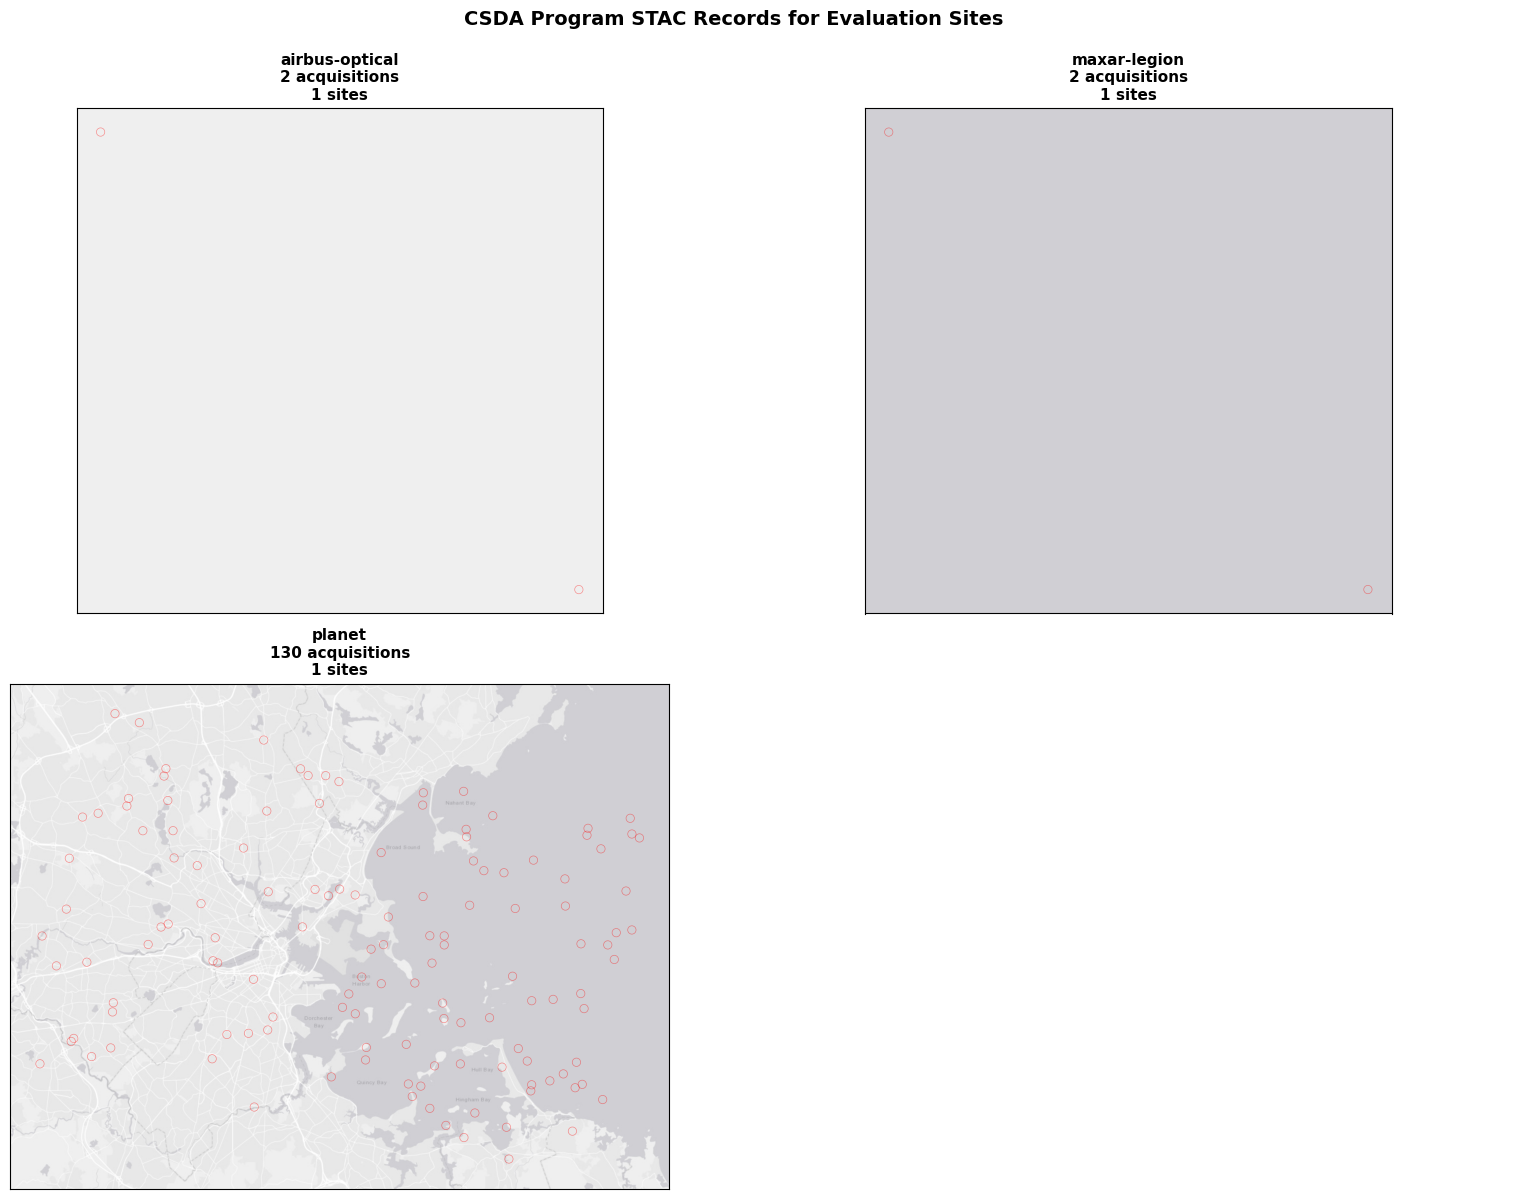

In [105]:
fig = staclib.plot_collections_map(stac_gdf, show_stats=True)
plt.show()

### Plot site maps for acquisitions

In [108]:
CLOUD_MAX = 10 # for STAC records across multiple vendor, there are different cloud field names - need to crosswalk some key fields first to then more easily filter downstream

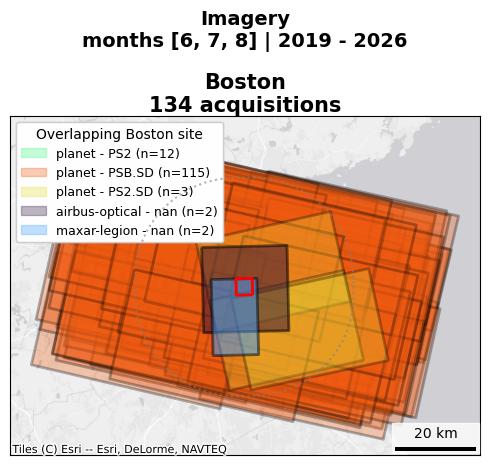

In [116]:
# Define gdf to plot
gdf_to_plot = stac_gdf

# Define sites to plot
sites_to_plot = sorted([site for site in gdf_to_plot.site_name.unique() if site != 'Not CSDA Eval Site'])

# Create grid
n_sites = len(sites_to_plot)

if n_sites > 5:
    n_cols = 5
else:
    n_cols = n_sites
    
n_rows = int(np.ceil(n_sites / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols,5 * n_rows))

# Flatten axes
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for idx, site_name in enumerate(sites_to_plot):
    csdalib.plot_site_coverage(
        site_name,
        gdf_to_plot,
        sites_gdf,
        BUF_KM_TOTAL_FOR_DISPLAY,
        sites_buf_gdf=sites_gdf_buf_display,
        site_name_field='site_name',
        id_field='id',
        affiliation_field='collection',
        constellation_field='eo:instrument',
        ax=axes[idx],
    )

# Hide unused subplots
for idx in range(len(sites_to_plot), len(axes)):
    axes[idx].set_visible(False)

# Add main title
plt.suptitle(f"Imagery\nmonths {MONTH_LIST} | {pd.to_datetime(START_DATE).year} - {pd.to_datetime(END_DATE).year}", fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

## Heatmaps provides info on amount of overlap at a site

#### static, all sites for each collection

Calculating global count range...
Global count range: 1 - 127


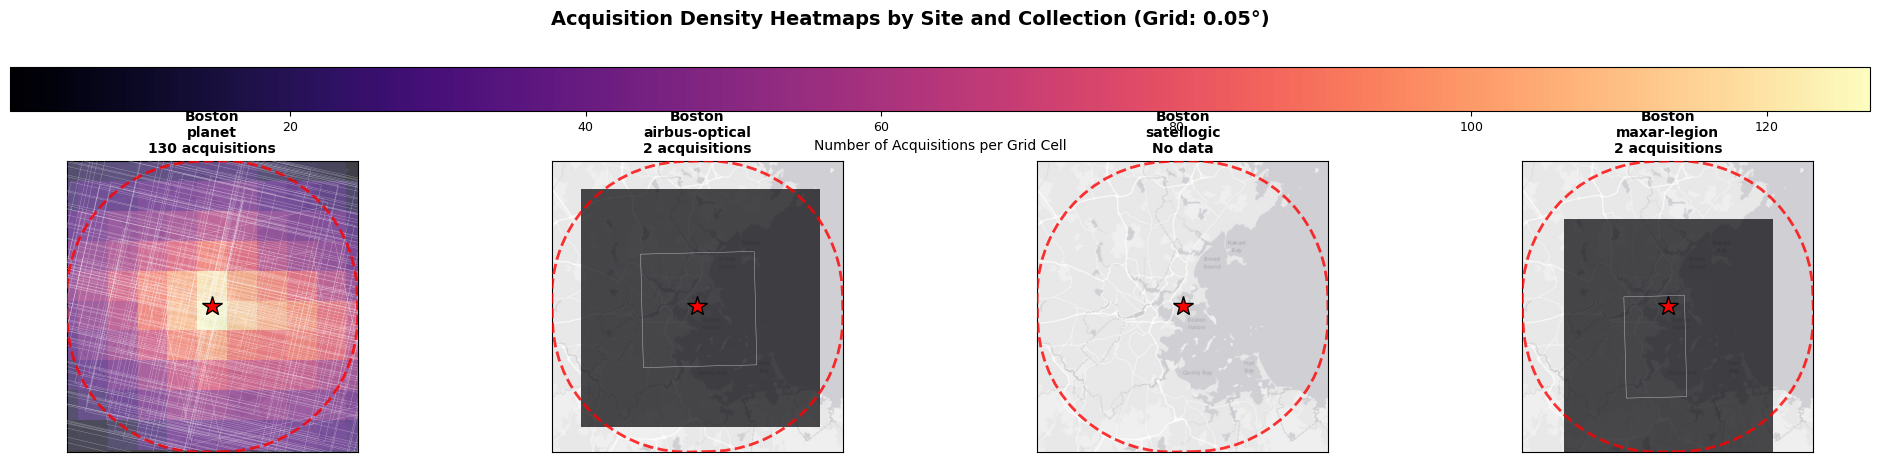

In [109]:
# Use it
all_grids, fig = staclib.create_acquisition_heatmap_multi(
    stac_gdf,
    sites_gdf,
    sites_gdf_buf_display,
    site_name_field='site_name',
    site_name_field_sites='Site Name',
    # collections=['planet', 'satellogic'],
    # sites=['PICS Libya-4', 'Casablanca'],
    collections=COLLECTION_LIST,
    sites=None,
    grid_size=0.05,
    cmap='magma'
)

plt.show()

#### interactive for 1 site, collection

In [111]:
m, grid_gdf = staclib.create_interactive_heatmap(
    stac_gdf,
    collection_name=COLLECTION_LIST[0],
    grid_size=0.01,
    cmap='magma',
    site_name='Boston'
)

# m.save('heatmap.html')
m

Creating heatmap for 130 acquisitions
Grid cells with data: 5500
Acquisition count range: 1 - 112
Could not parse dates: Invalid isoformat string: '2019-07-27T15:12:59.50825+00:00'
